# Exercice 1

# Exercice 2

# Exercice 3 
Transformations linéaire
Notebook poisson_enonce.ipynb

1. Les coordonnées des points de l’image de Argyropelecus offers sont donnéesdans
le fichier coords.npy. Charger ce fichier et donner une image de Argyropelecus
offers.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
#load coords.npy
df = np.load('coords.npy')

print(df)
print(type(df))
print(df.shape)

[[151 151 150 ...   1   0   0]
 [ 95  96   3 ... 106 105 106]]
<class 'numpy.ndarray'>
(2, 5957)


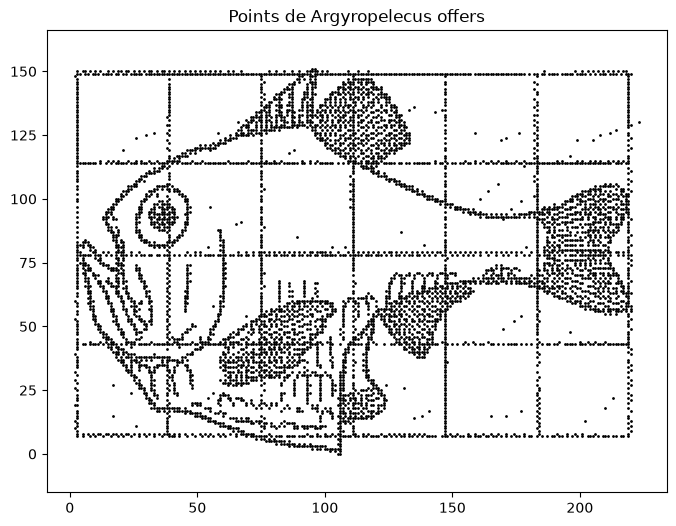

In [2]:
x = df[1, :]
y = df[0, :]

plt.figure(figsize=(8, 6))
plt.plot(x, y, '.', markersize=2, color='black')  # chaque point
plt.axis('equal')
plt.title("Points de Argyropelecus offers")
plt.show()

2. Déterminez la matrice de la transformation et appliquez la sur la figure précé
dente

je dois appliquer la T : [1,0.5/0,1] à mes coordonnées de chq point du poissone existant

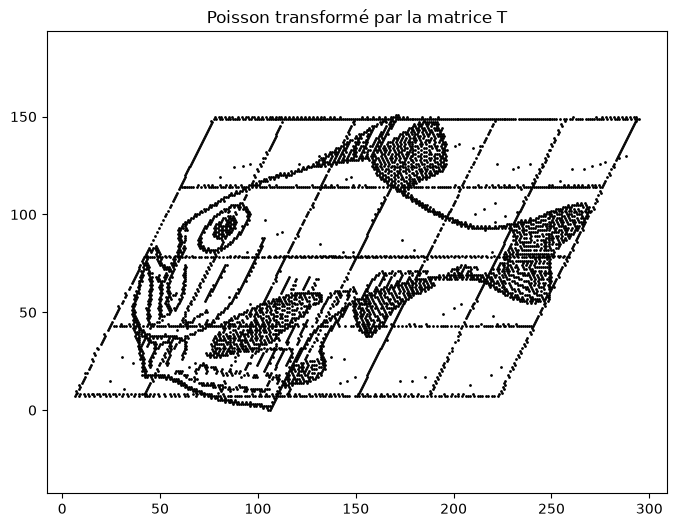

In [3]:
T = np.array([[1, 0.5],
              [0, 1]]) #ma transformation

# Application de la transformation à tous les vecteurs
transformed = T @ np.vstack([x, y])   # produit matriciel

x_new = transformed[0]
y_new = transformed[1]

plt.figure(figsize=(8, 6))
plt.plot(x_new, y_new, '.', markersize=2, color='black')
plt.axis('equal')
plt.title("Poisson transformé par la matrice T")
plt.show()

# Exercice 4 : Analyse en composantes principales
Le fichier mtcars.csv contient les résultats de tests routiers effectués par le magazine
Motor Trend en 1974 sur 32 modèles de voitures de l’année 1973-1974. Onze variables
décrivant les caractéristiques techniques et les performances des différents modèles
ont été enregistrées.
Nous allons utiliser ces données pour explorer les calculs de l’analyse en composantes
principales (ACP).


## 1. Chargez les données et sélectionnez les 10 premiers modèles et les 3 premières variables.

In [4]:
import pandas as pd
df_cars = pd.read_csv(r"..\data\mtcars.csv", sep=",", encoding='utf-8')
print(type(df_cars))


<class 'pandas.DataFrame'>


In [5]:
print(df_cars.columns)


Index(['Unnamed: 0', 'mpg', 'cyl', 'disp', 'hp', 'drat', 'wt', 'qsec', 'vs',
       'am', 'gear', 'carb'],
      dtype='str')


In [6]:
df_cars.columns.values[0] = "model"


In [7]:
print(df_cars.iloc[:10, :3].to_string())


               model   mpg  cyl
0          Mazda RX4  21.0    6
1      Mazda RX4 Wag  21.0    6
2         Datsun 710  22.8    4
3     Hornet 4 Drive  21.4    6
4  Hornet Sportabout  18.7    8
5            Valiant  18.1    6
6         Duster 360  14.3    8
7          Merc 240D  24.4    4
8           Merc 230  22.8    4
9           Merc 280  19.2    6


## 2. Nous savons que l’ACP peut être réalisée grâce à la décomposition en valeurs propres de la matrice de covariance ou de corrélation.


a. Rappelez le calcul de la matrice de covariance 𝗩 et de corrélation 𝗥 à partir
de la matrice des données 𝗗.


Déjà on a la matrice D de dimension n x p avec n =32 modèles de voitures et p = 11 variables représentants les caractéristiques techiniques. xij est la valeur de la varibale j pour le modèle de voiture i. 
Cette matrice D est rectangulaire, pour l'avoir en carré pour ensuite qu'elle soit diagonalisable il faut la transformer en matrice de covariance V ou de corrélation R. 

Le calcul pour la matrice de covariance V= (1/
𝑛−1)*D⊤D 
avec la variance (xi) = (1/n-1) * somme de (xi-x)².  T la transposée de D c'est à dire qu'on a échangé colonne et lignes. DT est de forme p x n. Pour obtenir V on a multiplié D par DT. 

Meme calcul pour la R mais il faut que ce soit centré et normé = R = V normalisée. Pour cela, on fait la moyenne de chaque variable j avec xj =(1/n)*somme de xij. Le Dcentré qu'on obtient = D - 1n xT avec 1n = le vecteur colonne de n et xT le vecteur des moyennes des variables. Puis il faut standardiser donc on divise l'écart type de chaque variable. Dréduite = Dcentré * S^-1. S étant la matrice diagonale des écarts-types. R = 1/n Dréduite T Dréduite = S^-1 V S^-1. 
R est une matrice symétrique avec une diagonale de 1 car chaque variable est corrélée avec elle même. 

b. Calculez la matrice de covariance des données sélectionnées de deux façons
différentes. 

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = df_cars.select_dtypes(include='number')  # garde uniquement les colonnes numériques donc pas la 1 qui donne les modèles des voitures

n = df.shape[0]  # 32
p = df.shape[1]  # 11

mean = {}
for col in df.columns:
    mean[col] = sum(df[col]) / n #on veut la moyenne d'une var sur les 32 lignes (modèle de voiture)

V = pd.DataFrame(0.0, index=df.columns, columns=df.columns) #on creer une matrice vide avec le nom des lignes = nom des colonnes pour avoir une matrice p x p
#puis on rempli
for col_j in df.columns:
    for col_k in df.columns:
        diff_product_sum = 0
        for i in range(n):
            diff_j = df[col_j].iloc[i] - mean[col_j]
            diff_k = df[col_k].iloc[i] - mean[col_k]
            diff_product_sum += diff_j * diff_k
        V.loc[col_j, col_k] = diff_product_sum / (n - 1)

print(V)


             mpg         cyl          disp           hp       drat  \
mpg    36.324103   -9.172379   -633.097208  -320.732056   2.195064   
cyl    -9.172379    3.189516    199.660282   101.931452  -0.668367   
disp -633.097208  199.660282  15360.799829  6721.158669 -47.064019   
hp   -320.732056  101.931452   6721.158669  4700.866935 -16.451109   
drat    2.195064   -0.668367    -47.064019   -16.451109   0.285881   
wt     -5.116685    1.367371    107.684204    44.192661  -0.372721   
qsec    4.509149   -1.886855    -96.051681   -86.770081   0.087141   
vs      2.017137   -0.729839    -44.377621   -24.987903   0.118649   
am      1.803931   -0.465726    -36.564012    -8.320565   0.190151   
gear    2.135685   -0.649194    -50.802621    -6.358871   0.275988   
carb   -5.363105    1.520161     79.068750    83.036290  -0.078407   

              wt       qsec         vs         am       gear       carb  
mpg    -5.116685   4.509149   2.017137   1.803931   2.135685  -5.363105  
cyl     1.3

In [ ]:
#autre façon 
n = df.shape[0]  # nombre de modèles (lignes =32) 

# On soustrait la moyenne de chaque colonne
df_centre = df - df.mean(axis=0)

V_2 = (df_centre.T @ df_centre) / (n - 1)

print("Matrice de covariance  :\n", V_2)

Matrice de covariance  :
              mpg         cyl          disp           hp       drat  \
mpg    36.324103   -9.172379   -633.097208  -320.732056   2.195064   
cyl    -9.172379    3.189516    199.660282   101.931452  -0.668367   
disp -633.097208  199.660282  15360.799829  6721.158669 -47.064019   
hp   -320.732056  101.931452   6721.158669  4700.866935 -16.451109   
drat    2.195064   -0.668367    -47.064019   -16.451109   0.285881   
wt     -5.116685    1.367371    107.684204    44.192661  -0.372721   
qsec    4.509149   -1.886855    -96.051681   -86.770081   0.087141   
vs      2.017137   -0.729839    -44.377621   -24.987903   0.118649   
am      1.803931   -0.465726    -36.564012    -8.320565   0.190151   
gear    2.135685   -0.649194    -50.802621    -6.358871   0.275988   
carb   -5.363105    1.520161     79.068750    83.036290  -0.078407   

              wt       qsec         vs         am       gear       carb  
mpg    -5.116685   4.509149   2.017137   1.803931   2.13568

In [11]:
#autre facon en utilisant panda
cov_df = df.cov()
print(cov_df)

             mpg         cyl          disp           hp       drat  \
mpg    36.324103   -9.172379   -633.097208  -320.732056   2.195064   
cyl    -9.172379    3.189516    199.660282   101.931452  -0.668367   
disp -633.097208  199.660282  15360.799829  6721.158669 -47.064019   
hp   -320.732056  101.931452   6721.158669  4700.866935 -16.451109   
drat    2.195064   -0.668367    -47.064019   -16.451109   0.285881   
wt     -5.116685    1.367371    107.684204    44.192661  -0.372721   
qsec    4.509149   -1.886855    -96.051681   -86.770081   0.087141   
vs      2.017137   -0.729839    -44.377621   -24.987903   0.118649   
am      1.803931   -0.465726    -36.564012    -8.320565   0.190151   
gear    2.135685   -0.649194    -50.802621    -6.358871   0.275988   
carb   -5.363105    1.520161     79.068750    83.036290  -0.078407   

              wt       qsec         vs         am       gear       carb  
mpg    -5.116685   4.509149   2.017137   1.803931   2.135685  -5.363105  
cyl     1.3

In [12]:
#ou en utilisant numpy
cov_matrix = np.cov(df, rowvar=False) # variables sont en colonnes (pas en lignes) avec rowvar=False
print(cov_matrix)


[[ 3.63241028e+01 -9.17237903e+00 -6.33097208e+02 -3.20732056e+02
   2.19506351e+00 -5.11668468e+00  4.50914919e+00  2.01713710e+00
   1.80393145e+00  2.13568548e+00 -5.36310484e+00]
 [-9.17237903e+00  3.18951613e+00  1.99660282e+02  1.01931452e+02
  -6.68366935e-01  1.36737097e+00 -1.88685484e+00 -7.29838710e-01
  -4.65725806e-01 -6.49193548e-01  1.52016129e+00]
 [-6.33097208e+02  1.99660282e+02  1.53607998e+04  6.72115867e+03
  -4.70640192e+01  1.07684204e+02 -9.60516815e+01 -4.43776210e+01
  -3.65640121e+01 -5.08026210e+01  7.90687500e+01]
 [-3.20732056e+02  1.01931452e+02  6.72115867e+03  4.70086694e+03
  -1.64511089e+01  4.41926613e+01 -8.67700806e+01 -2.49879032e+01
  -8.32056452e+00 -6.35887097e+00  8.30362903e+01]
 [ 2.19506351e+00 -6.68366935e-01 -4.70640192e+01 -1.64511089e+01
   2.85881351e-01 -3.72720726e-01  8.71407258e-02  1.18649194e-01
   1.90151210e-01  2.75987903e-01 -7.84072581e-02]
 [-5.11668468e+00  1.36737097e+00  1.07684204e+02  4.41926613e+01
  -3.72720726e-01  

In [ ]:
# Vérifie que les 2 matrices sont égales à une tolérance numérique près
print(np.allclose(V, V_2))  # renvoie True si les écarts sont négligeables

True


# VISUALISATION

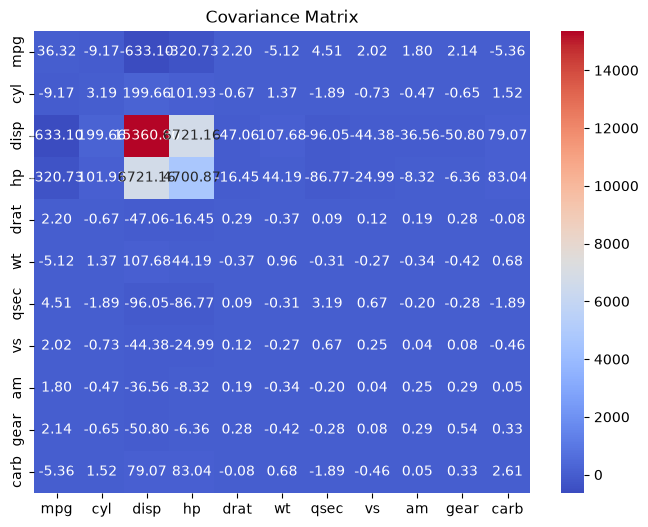

In [14]:

plt.figure(figsize=(8,6))
sns.heatmap(V, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Covariance Matrix')
plt.show()

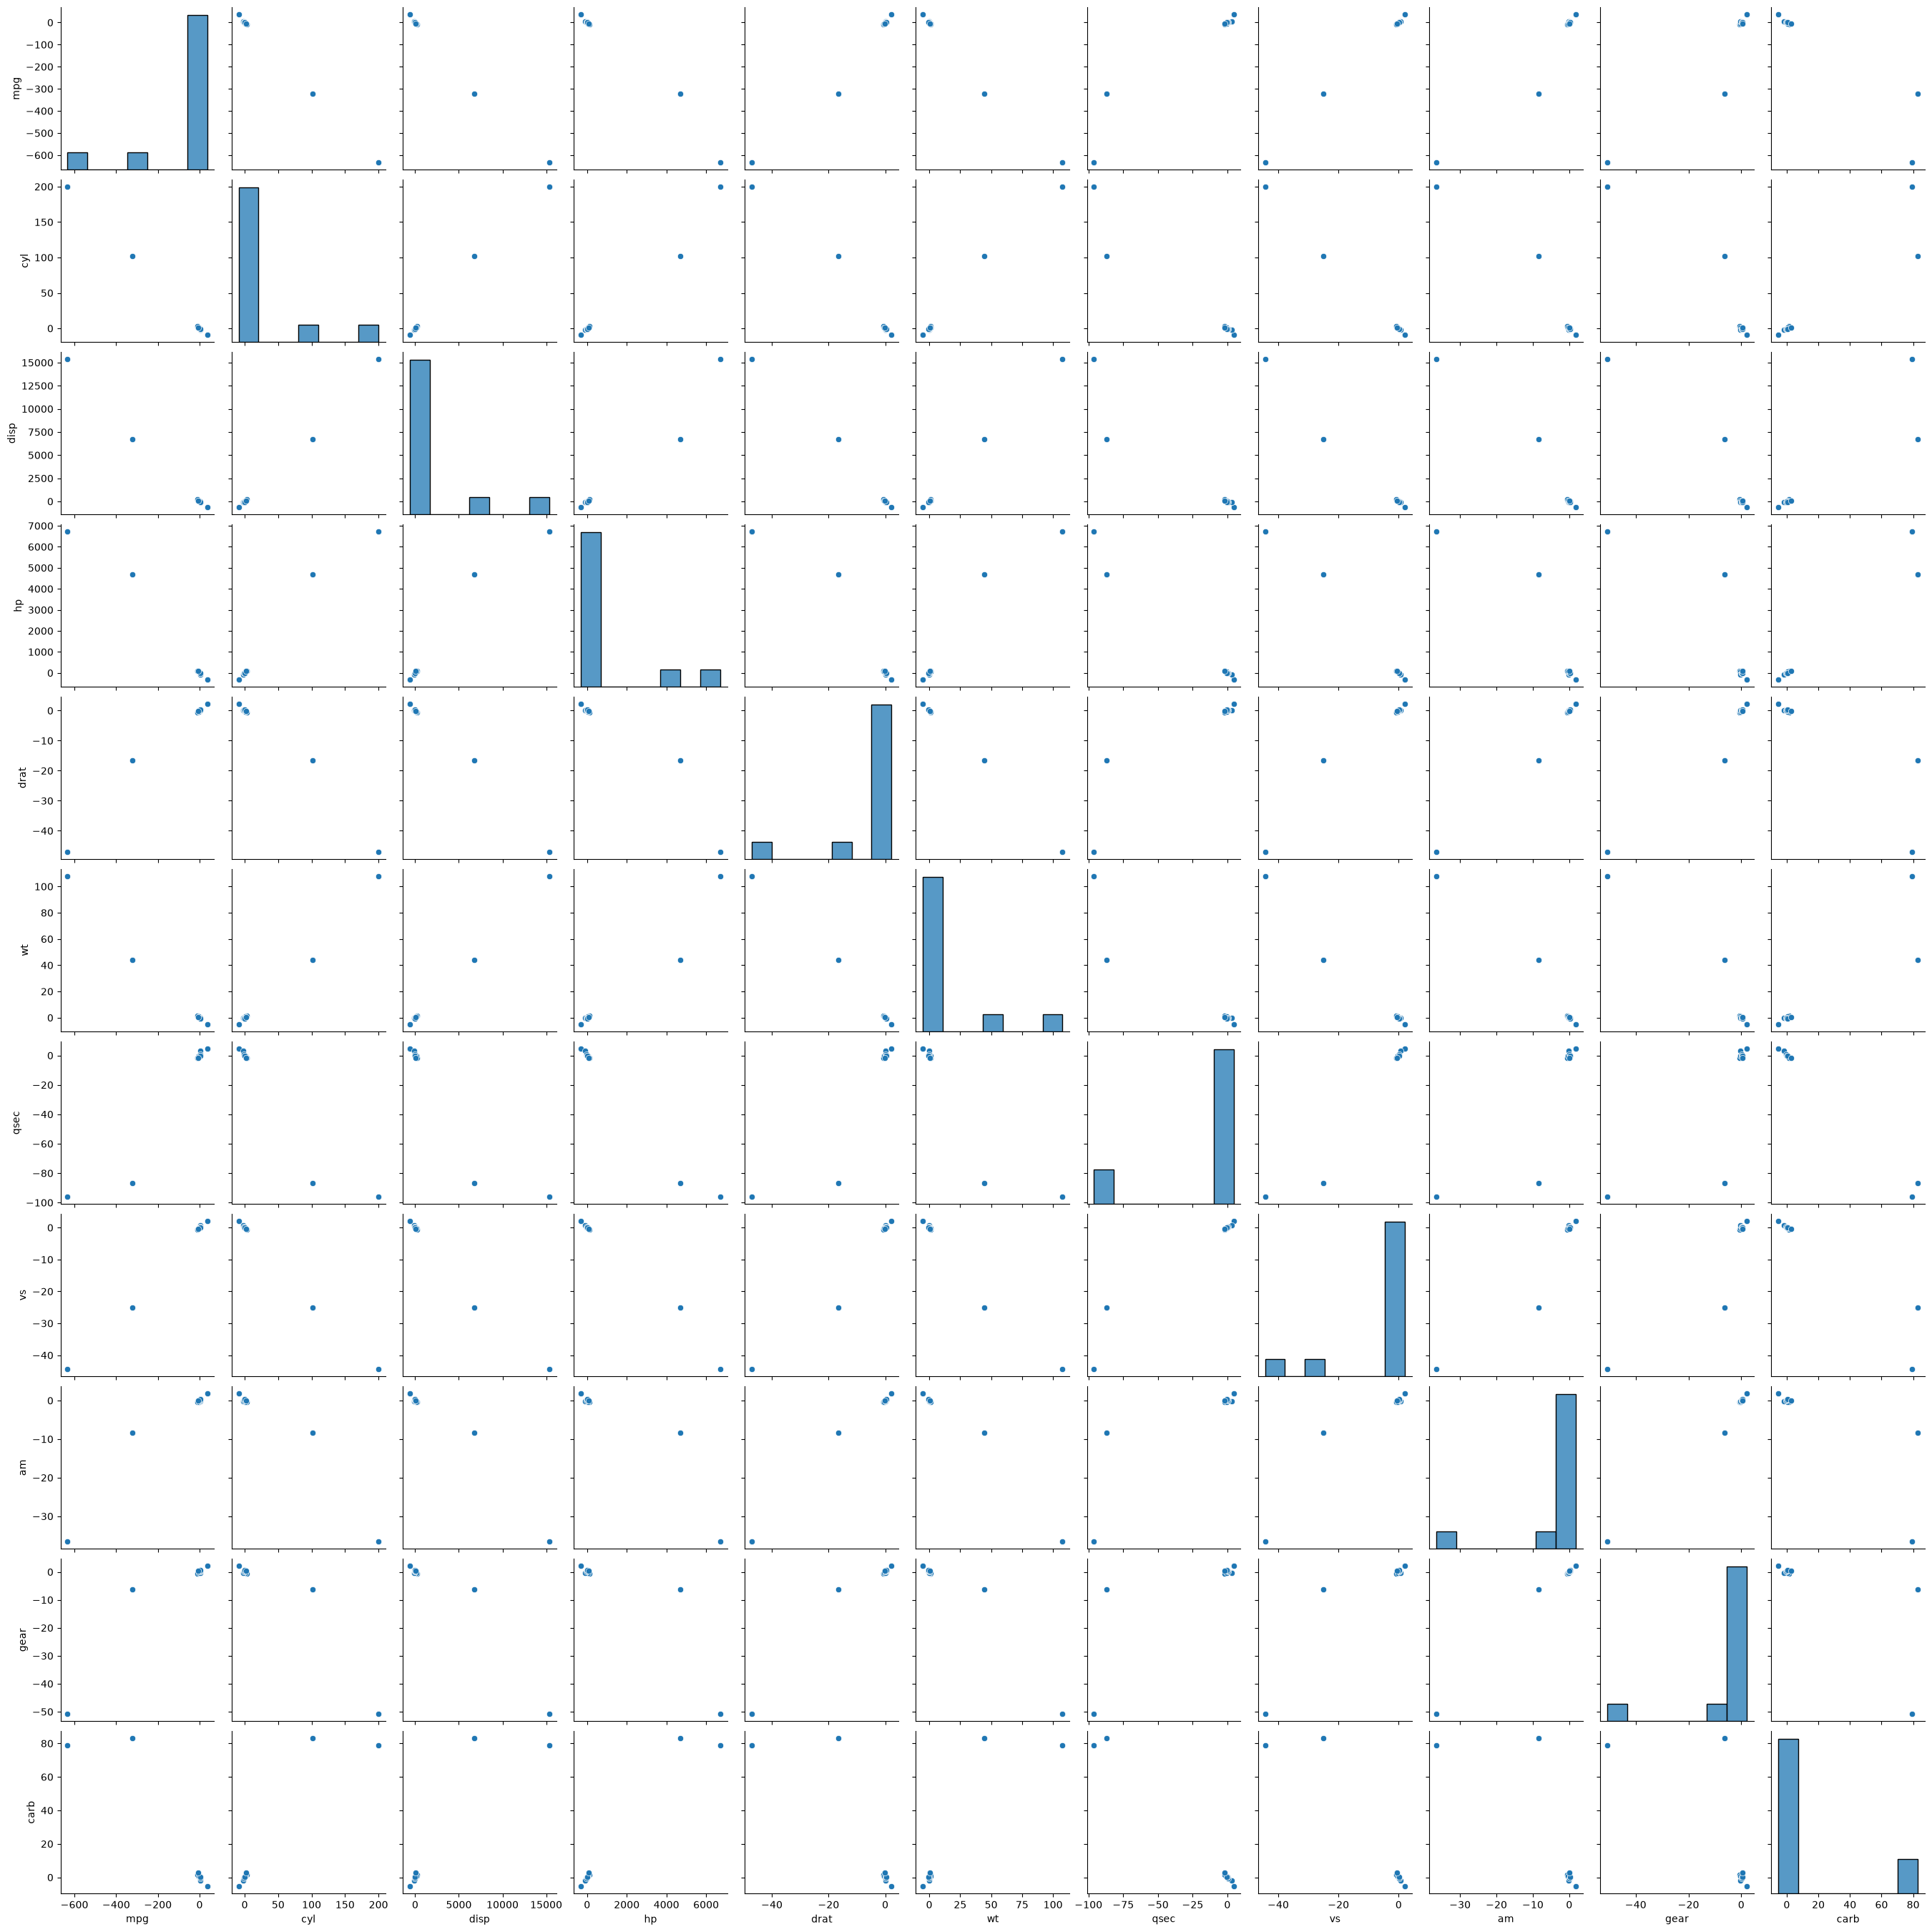

In [15]:

import seaborn as sns
sns.pairplot(V)
plt.show()

# 3. Nous allons réaliser l’analyse en composantes principales (ACP) des données sélectionnées en utilisant la diagonalisation de la matrice de covariance ou decorrélation.
a. Réalisez une décomposition en valeurs propres (diagonalisation) de la matrice de covariance et de la matrice de corrélation grâce à la commande linalg.eig du module numpy.

In [ ]:
from numpy import linalg as LA

eigenvalues_V, eigenvectors_V = LA.eigh(V)

print("Valeurs propres de V :\n", eigenvalues_V)
print("\nVecteurs propres de V :\n", eigenvectors_V)


Valeurs propres de V :
 [3.93719949e-02 4.43742434e-02 6.28491258e-02 8.17733529e-02
 9.52210464e-02 4.40286790e-01 8.21717176e-01 1.70733638e+00
 9.43114274e+00 1.45527582e+03 1.86412732e+04]

Vecteurs propres de V :
 [[ 1.58569365e-02  3.06303615e-02  2.79013881e-03  2.27104005e-02
   3.92391738e-02 -1.43790084e-01  8.83284292e-02 -4.76347838e-02
  -9.82070847e-01  9.18484655e-03 -3.81181985e-02]
 [-1.45445363e-01  1.31718534e-01 -4.26772061e-02 -1.89040332e-01
  -4.25011021e-01 -7.93818050e-01 -2.38725898e-01  2.27991962e-01
   6.34839420e-02 -3.37248716e-03  1.20351498e-02]
 [-9.42026215e-04 -5.39913212e-03 -3.53271286e-03 -5.84146399e-04
  -5.82397980e-04  7.42413761e-03  1.07359688e-02  5.08682642e-03
  -3.14426562e-02  4.35372320e-01  8.99568146e-01]
 [ 2.15261018e-03  1.86255377e-03  3.73408459e-03  4.74808676e-06
   2.21253798e-03  1.65368455e-03 -1.65519386e-02 -3.57156383e-02
  -2.50930486e-02 -8.99307303e-01  4.34784387e-01]
 [ 9.73818815e-02  1.84102094e-01  1.41311095e-02

In [ ]:
# pour la matrice de correl R il faut d'abord la calculer: 
R = df.corr()
print(R)

           mpg       cyl      disp        hp      drat        wt      qsec  \
mpg   1.000000 -0.852162 -0.847551 -0.776168  0.681172 -0.867659  0.418684   
cyl  -0.852162  1.000000  0.902033  0.832447 -0.699938  0.782496 -0.591242   
disp -0.847551  0.902033  1.000000  0.790949 -0.710214  0.887980 -0.433698   
hp   -0.776168  0.832447  0.790949  1.000000 -0.448759  0.658748 -0.708223   
drat  0.681172 -0.699938 -0.710214 -0.448759  1.000000 -0.712441  0.091205   
wt   -0.867659  0.782496  0.887980  0.658748 -0.712441  1.000000 -0.174716   
qsec  0.418684 -0.591242 -0.433698 -0.708223  0.091205 -0.174716  1.000000   
vs    0.664039 -0.810812 -0.710416 -0.723097  0.440278 -0.554916  0.744535   
am    0.599832 -0.522607 -0.591227 -0.243204  0.712711 -0.692495 -0.229861   
gear  0.480285 -0.492687 -0.555569 -0.125704  0.699610 -0.583287 -0.212682   
carb -0.550925  0.526988  0.394977  0.749812 -0.090790  0.427606 -0.656249   

            vs        am      gear      carb  
mpg   0.664039  

In [18]:
eigenvalues_R, eigenvectors_R = LA.eigh(R)

print("Valeurs propres de R :\n", eigenvalues_R)
print("\nVecteurs propres de R :\n", eigenvectors_R)

Valeurs propres de R :
 [0.02204441 0.05203544 0.07704665 0.12290143 0.13526199 0.21159612
 0.2234511  0.26959744 0.62719727 2.65046789 6.60840025]

Vecteurs propres de R :
 [[ 0.12489563 -0.13928524 -0.23570162  0.75409142 -0.36772381  0.10879743
  -0.10284468 -0.02254025  0.22574419 -0.0161244  -0.3625305 ]
 [ 0.14069544  0.84641949 -0.05403527  0.23082493 -0.05727774 -0.16855369
  -0.05848381 -0.00259184  0.17531118 -0.04374371  0.37391603]
 [-0.66060648 -0.04937979 -0.19842785 -0.00114213 -0.21430308  0.33616451
  -0.3939953   0.25660788  0.06148414  0.04932413  0.3681852 ]
 [ 0.25649206 -0.24782351  0.57583007  0.22235844  0.00149599 -0.07143563
  -0.54004744 -0.06767616 -0.14001476 -0.24878402  0.33005692]
 [ 0.03953025  0.10149369  0.04690123 -0.0321935  -0.02111986 -0.24449705
  -0.07732727  0.85482874 -0.16118879 -0.27469408 -0.29415138]
 [ 0.5674487  -0.09439426 -0.35949825  0.00857193  0.0206683   0.46493964
   0.07502912  0.24589931 -0.34181851  0.14303825  0.34610332]
 [-0

# b) Verification que la base soit orthonormé 

In [ ]:
 #--> U étant une matrice avec chq colonne un vecteur propre. la base est orthonormé si : UT*U = I
result = eigenvectors_V.T @ eigenvectors_V
print(result)
#la diag doit etre 1 (car chq vecteur a une norme de 1) et hors diag 0 (car les vecteurs sont perpendiculaires entre eux)
# Vérification : ça doit être proche de la matrice identité --> Si true = c'est bon
print(np.allclose(result, np.identity(eigenvectors_V.shape[0])))

[[ 1.00000000e+00  2.71151903e-16 -1.68353878e-16  3.40820234e-17
  -1.70162647e-17 -6.26274315e-17  1.47086312e-16  9.81476224e-17
   2.14442182e-18  8.02162442e-18  5.19021293e-17]
 [ 2.71151903e-16  1.00000000e+00  5.18612907e-17 -4.30654104e-16
  -4.66227788e-17 -5.44305023e-17  1.32159667e-16  1.19628314e-16
  -1.62928414e-18 -3.34624259e-17 -2.65821202e-17]
 [-1.68353878e-16  5.18612907e-17  1.00000000e+00 -1.43494127e-17
   1.04568787e-16  4.35785873e-17 -1.46658146e-17  1.52650314e-17
  -1.10340078e-17 -2.25511379e-18  1.30288081e-17]
 [ 3.40820234e-17 -4.30654104e-16 -1.43494127e-17  1.00000000e+00
  -2.47760171e-16 -2.74368885e-16 -1.21593123e-16  2.52215782e-16
  -2.19125782e-17  3.66235421e-18  4.77049380e-17]
 [-1.70162647e-17 -4.66227788e-17  1.04568787e-16 -2.47760171e-16
   1.00000000e+00 -2.08380485e-16  1.65871954e-16  3.07160430e-16
  -3.38923785e-17  7.10589637e-17  1.10506889e-16]
 [-6.26274315e-17 -5.44305023e-17  4.35785873e-17 -2.74368885e-16
  -2.08380485e-16  

# autre facon - à choisir

In [20]:
#normalité : chq vecteur propre a une norme egale à 1
for i in range(eigenvectors_V.shape[1]):
    norme = np.linalg.norm(eigenvectors_V[:, i])
    print(f"Norme du vecteur propre {i} : {norme:.6f}")

Norme du vecteur propre 0 : 1.000000
Norme du vecteur propre 1 : 1.000000
Norme du vecteur propre 2 : 1.000000
Norme du vecteur propre 3 : 1.000000
Norme du vecteur propre 4 : 1.000000
Norme du vecteur propre 5 : 1.000000
Norme du vecteur propre 6 : 1.000000
Norme du vecteur propre 7 : 1.000000
Norme du vecteur propre 8 : 1.000000
Norme du vecteur propre 9 : 1.000000
Norme du vecteur propre 10 : 1.000000


In [21]:
#orthogonalité : chq paire de v propres diff a un prod scalaire nul
v1 = eigenvectors_V[:, 0]
v2 = eigenvectors_V[:, 1]
print("Produit scalaire v1.v2 :", np.dot(v1, v2))  # doit être proche de 0

Produit scalaire v1.v2 : 2.7755575615628914e-16


# Visualisation

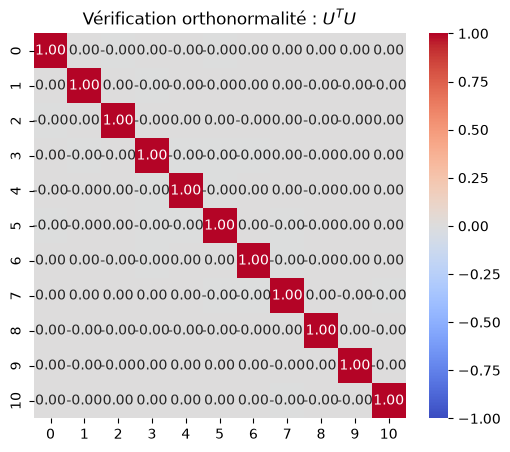

In [22]:
plt.figure(figsize=(6, 5))
sns.heatmap(result, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, center=0)
plt.title('Vérification orthonormalité : $U^T U$')
plt.show()

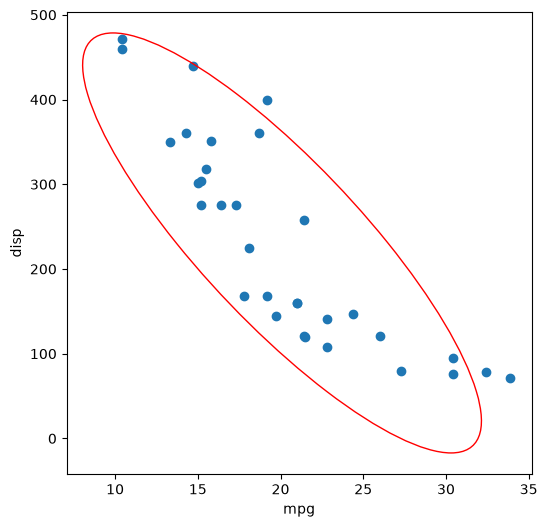

In [58]:
from matplotlib.patches import Ellipse

def plot_covariance_ellipse(x, y, ax, n_std=2.0, **kwargs):
    cov = np.cov(x, y)
    mean_x, mean_y = np.mean(x), np.mean(y)
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    order = eigenvalues.argsort()[::-1]
    eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]
    angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(eigenvalues)
    ellipse = Ellipse((mean_x, mean_y), width, height, angle=angle, fill=False, **kwargs)
    ax.add_patch(ellipse)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(df['mpg'], df['disp'])
plot_covariance_ellipse(df['mpg'], df['disp'], ax, edgecolor='red')
plt.xlabel('mpg'); plt.ylabel('disp')
plt.show()

# c)  La somme des valeurs propres représente la variance totale des données. Ordonnez les valeurs propres en ordre décroissant et calculez le pourcentage de variance correspondant à chacune d’entre elles. Comparez les pourcentages obtenus selon la matrice sur laquelle est appliquée la diagonalisation

In [ ]:
ordre = np.argsort(eigenvalues_V)[::-1] # Tri décroissant
valeurs_propres = eigenvalues_V[ordre]

print("Valeurs propres triées (décroissant) :\n", valeurs_propres)
for i, val in enumerate(valeurs_propres, start=1):
    print(f"λ{i} = {val:.4f}")

Valeurs propres triées (décroissant) :
 [1.86412732e+04 1.45527582e+03 9.43114274e+00 1.70733638e+00
 8.21717176e-01 4.40286790e-01 9.52210464e-02 8.17733529e-02
 6.28491258e-02 4.43742434e-02 3.93719949e-02]
λ1 = 18641.2732
λ2 = 1455.2758
λ3 = 9.4311
λ4 = 1.7073
λ5 = 0.8217
λ6 = 0.4403
λ7 = 0.0952
λ8 = 0.0818
λ9 = 0.0628
λ10 = 0.0444
λ11 = 0.0394


In [51]:
var = valeurs_propres / valeurs_propres.sum() * 100
print("Variance expliquée par valeur propre(%) :", var)
for i, val in enumerate(var, start=1):
    print(f"λ{i} = {val:.4f}%")

Variance expliquée par valeur propre(%) : [9.26998858e+01 7.23683953e+00 4.68994713e-02 8.49029388e-03
 4.08625997e-03 2.18947144e-03 4.73518094e-04 4.06644997e-04
 3.12538030e-04 2.20665577e-04 1.95790244e-04]
λ1 = 92.6999%
λ2 = 7.2368%
λ3 = 0.0469%
λ4 = 0.0085%
λ5 = 0.0041%
λ6 = 0.0022%
λ7 = 0.0005%
λ8 = 0.0004%
λ9 = 0.0003%
λ10 = 0.0002%
λ11 = 0.0002%


# On a regardé pour la matrice de covariance V, à présent on va comparer ce qu'on a obtenu avec la matrice de correlation R


In [78]:
ordre = np.argsort(eigenvalues_R)[::-1] # Tri décroissant
valeurs_propresR = eigenvalues_R[ordre]

print("Valeurs propres triées (décroissant) :\n", valeurs_propresR)
for i, val in enumerate(valeurs_propresR, start=1):
    print(f"λ{i} = {val:.4f}")

varR = valeurs_propresR / valeurs_propresR.sum() * 100
print("Variance expliquée par valeur propre(%) :", varR)
for i, val in enumerate(varR, start=1):
    print(f"λ{i} = {val:.4f}%")
    

Valeurs propres triées (décroissant) :
 [6.60840025 2.65046789 0.62719727 0.26959744 0.2234511  0.21159612
 0.13526199 0.12290143 0.07704665 0.05203544 0.02204441]
λ1 = 6.6084
λ2 = 2.6505
λ3 = 0.6272
λ4 = 0.2696
λ5 = 0.2235
λ6 = 0.2116
λ7 = 0.1353
λ8 = 0.1229
λ9 = 0.0770
λ10 = 0.0520
λ11 = 0.0220
Variance expliquée par valeur propre(%) : [60.07636593 24.09516266  5.70179338  2.45088578  2.03137367  1.9236011
  1.22965443  1.11728575  0.70042414  0.47304946  0.20040369]
λ1 = 60.0764%
λ2 = 24.0952%
λ3 = 5.7018%
λ4 = 2.4509%
λ5 = 2.0314%
λ6 = 1.9236%
λ7 = 1.2297%
λ8 = 1.1173%
λ9 = 0.7004%
λ10 = 0.4730%
λ11 = 0.2004%


In [76]:
tableau_comparaison = pd.DataFrame({
    "λ (V)": valeurs_propres,
    "% Variance (V)": var,
    "λ (R)": valeurs_propresR,
    "% Variance (R)": varR
}, index=[f"λ{i}" for i in range(1, len(valeurs_propres) + 1)])

print(tableau_comparaison.round(4))

          λ (V)  % Variance (V)   λ (R)  % Variance (R)
λ1   18641.2732         92.6999  6.6084         60.0764
λ2    1455.2758          7.2368  2.6505         24.0952
λ3       9.4311          0.0469  0.6272          5.7018
λ4       1.7073          0.0085  0.2696          2.4509
λ5       0.8217          0.0041  0.2235          2.0314
λ6       0.4403          0.0022  0.2116          1.9236
λ7       0.0952          0.0005  0.1353          1.2297
λ8       0.0818          0.0004  0.1229          1.1173
λ9       0.0628          0.0003  0.0770          0.7004
λ10      0.0444          0.0002  0.0520          0.4730
λ11      0.0394          0.0002  0.0220          0.2004


# d) Les individus peuvent être représentés dans la nouvelle base des vecteurs propres en multipliant la matrice des données (centrées ou centrées et réduites) parla matrices des vecteurs propres. Donnez une représentation graphique desindividus dans le plan défini par les deux premiers vecteurs propres (après classement selon la variance expliquée)

In [ ]:
#transformer df en array numpy
D = df.values
#calcul de la PCA fait hypo que les données sont centrées, donc on va d'abord les std
from sklearn import preprocessing

std_scale = preprocessing.StandardScaler().fit(D)
D_scaled = std_scale.transform(D)
#on a une matrice de données centrées 

In [67]:
#On créer la matrice U = matrice de vecteurs propres de V (pxp = chaque colonne est un vecteur propre)
U = eigenvectors_R[:, ordre] # on veut garder le meme ordre decroissant que les valeurs propres

In [68]:
# on crée les composantes principales
CP = D_scaled @ U

à partir de la matrice de correl R

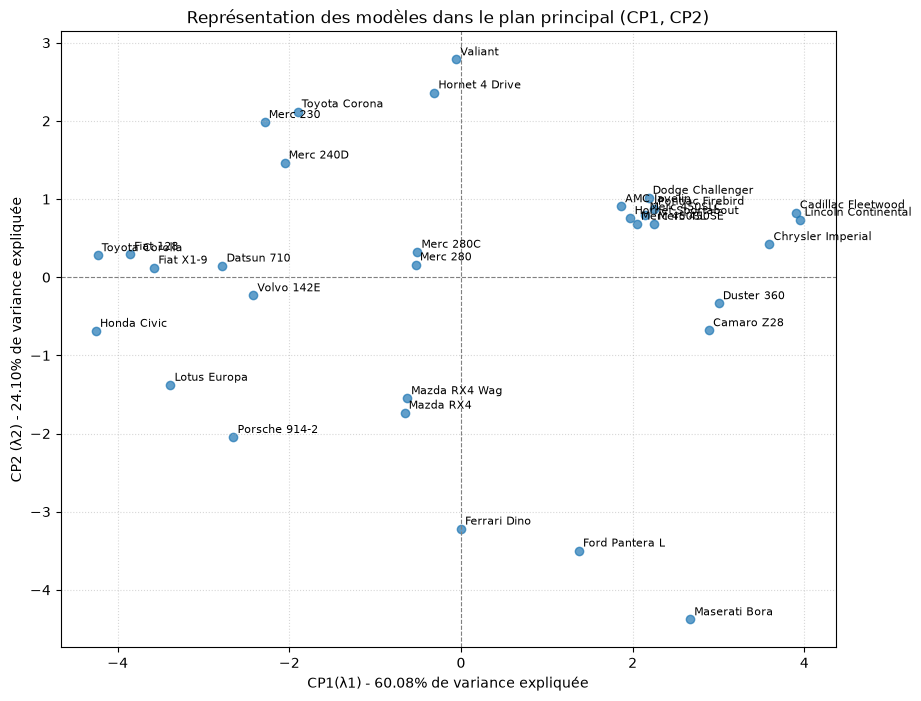

In [79]:
import matplotlib.pyplot as plt

# Récupération des deux premières composantes principales
CP1 = CP[:, 0]  # projection sur λ1
CP2 = CP[:, 1]  # projection sur λ2

# Noms des modèles de voitures (depuis le DataFrame original)
modele= df_cars['model'].values  # remplacez 'model' par le vrai nom de colonne

plt.figure(figsize=(10, 8))
plt.scatter(CP1, CP2, alpha=0.7)

# Annotation de chaque point avec le nom du modèle
for i in range(len(CP1)):
    plt.annotate(modele[i], (CP1[i], CP2[i]), fontsize=8, xytext=(3, 3), textcoords='offset points')

plt.axhline(0, color='grey', linewidth=0.8, linestyle='--')
plt.axvline(0, color='grey', linewidth=0.8, linestyle='--')

plt.xlabel(f"CP1(λ1) - {varR[0]:.2f}% de variance expliquée")
plt.ylabel(f"CP2 (λ2) - {varR[1]:.2f}% de variance expliquée")
plt.title("Représentation des modèles dans le plan principal (CP1, CP2)")
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

 # ou à partir de la matrice de covar V 

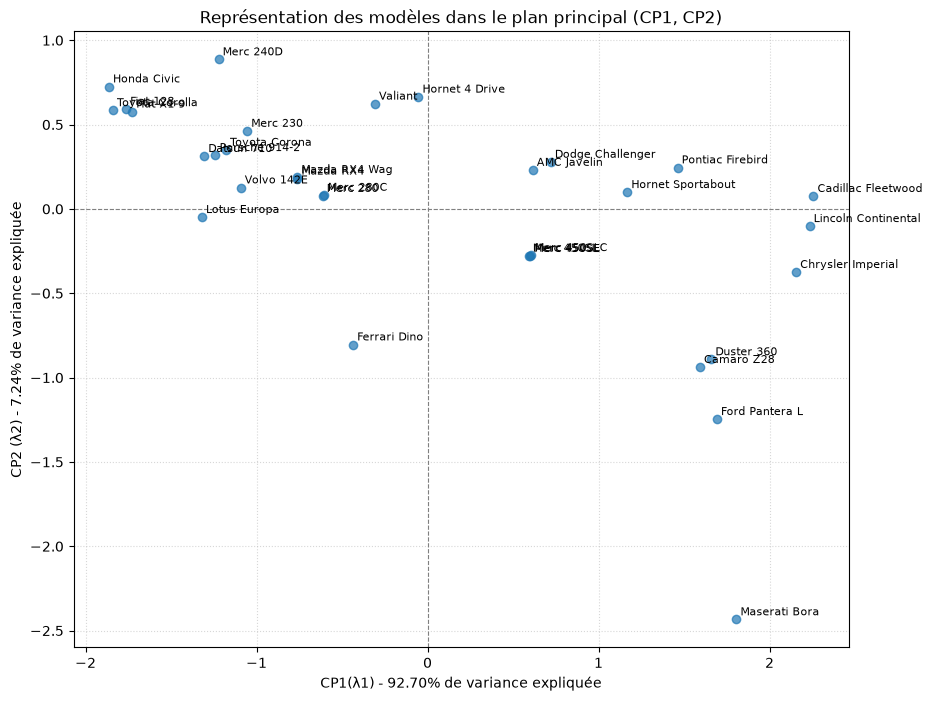

In [80]:
P = eigenvectors_V[:, ordre] # on veut garder le meme ordre decroissant que les valeurs propres
cp = D_scaled @ P

# Récupération des deux premières composantes principales
CP1 = cp[:, 0]  # projection sur λ1
CP2 = cp[:, 1]  # projection sur λ2

# Noms des modèles de voitures (depuis le DataFrame original)
modele= df_cars['model'].values  # remplacez 'model' par le vrai nom de colonne

plt.figure(figsize=(10, 8))
plt.scatter(CP1, CP2, alpha=0.7)

# Annotation de chaque point avec le nom du modèle
for i in range(len(CP1)):
    plt.annotate(modele[i], (CP1[i], CP2[i]), fontsize=8, xytext=(3, 3), textcoords='offset points')

plt.axhline(0, color='grey', linewidth=0.8, linestyle='--')
plt.axvline(0, color='grey', linewidth=0.8, linestyle='--')

plt.xlabel(f"CP1(λ1) - {var[0]:.2f}% de variance expliquée")
plt.ylabel(f"CP2 (λ2) - {var[1]:.2f}% de variance expliquée")
plt.title("Représentation des modèles dans le plan principal (CP1, CP2)")
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

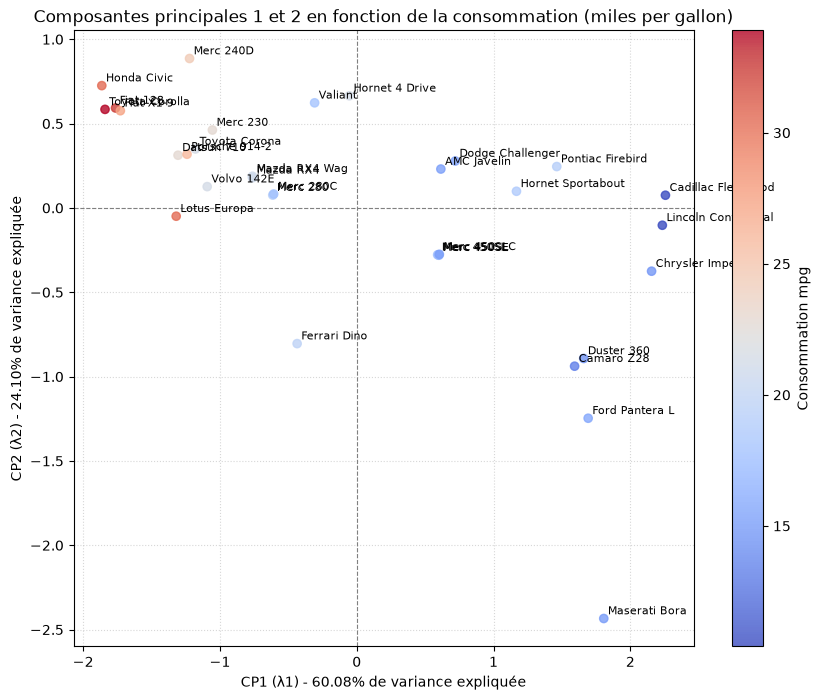

In [93]:
# Noms des modèles de voitures (index du DataFrame original)
modele= df_cars['model'].values

plt.figure(figsize=(10, 8))
sc = plt.scatter(cp[:, 0], cp[:, 1],
                  c=df_cars['mpg'], cmap='coolwarm', alpha=0.8)

plt.axhline(0, color='grey', linewidth=0.8, linestyle='--')
plt.axvline(0, color='grey', linewidth=0.8, linestyle='--')

# Annotation de chaque point avec le nom du modèle
for i in range(len(cp)):
    plt.annotate(modele[i], (cp[i, 0], cp[i, 1]), fontsize=8, xytext=(3, 3), textcoords='offset points')

plt.xlabel(f"CP1 (λ1) - {varR[0]:.2f}% de variance expliquée")
plt.ylabel(f"CP2 (λ2) - {varR[1]:.2f}% de variance expliquée")
plt.title("Composantes principales 1 et 2 en fonction de la consommation (miles per gallon)")
plt.colorbar(sc, label='Consommation mpg')
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

+ +le modele est de couleur chaude moins la voiture consomme 

# Question 4 : L’ACP peut aussi être obtenue grâce à la décomposition en valeurs singulières (SVD) de la matrice des données (centrées ou centrées et normées). Utilisez la fonction svd de la librairie linalg de numpy pour calculer la SVD de 𝗭. (Utilisez le paramètre full_matrices=False de façon à avoir: 𝗭 = 𝗨𝗦𝗩ℎ d’après les notations de numpy.)

In [97]:
Z = df.values - df.values.mean(axis=0) #données centrées
U, s, Vh = np.linalg.svd(Z, full_matrices=False) #SVD 
Z_reconstructed = U @ np.diag(s)@Vh #reconstruc Z
print(np.allclose (Z, Z_reconstructed)) #True 

True


# a ) Vérifiez que les carrés des valeurs singulières sont bien les variances en comparant avec les pourcentages de variances expliquées calculées ci dessus.

In [100]:
# les les valeurs propres de la mat de cov ou correl est egale à la variance - il faut faire les valeurs sing s ² /n-1
valeurs_propres_svd = (s**2) / (Z.shape[0] - 1)

# Pourcentage de variance expliquée via la SVD
var_svd = valeurs_propres_svd / valeurs_propres_svd.sum() * 100


print("Valeurs propres :\n", valeurs_propres_svd)
for i, val in enumerate(VPsvd, start=1):
    print(f"λ{i} = {val:.4f}")

print("Variance expliquée par valeur propre(%) :", var_svd)
for i, val in enumerate(var_svd, start=1):
    print(f"λ{i} = {val:.4f}%")
    


Valeurs propres :
 [1.86412732e+04 1.45527582e+03 9.43114274e+00 1.70733638e+00
 8.21717176e-01 4.40286790e-01 9.52210464e-02 8.17733529e-02
 6.28491258e-02 4.43742434e-02 3.93719949e-02]
λ1 = 18641.2732
λ2 = 1455.2758
λ3 = 9.4311
λ4 = 1.7073
λ5 = 0.8217
λ6 = 0.4403
λ7 = 0.0952
λ8 = 0.0818
λ9 = 0.0628
λ10 = 0.0444
λ11 = 0.0394
Variance expliquée par valeur propre(%) : [9.26998858e+01 7.23683953e+00 4.68994713e-02 8.49029388e-03
 4.08625997e-03 2.18947144e-03 4.73518094e-04 4.06644997e-04
 3.12538030e-04 2.20665577e-04 1.95790244e-04]
λ1 = 92.6999%
λ2 = 7.2368%
λ3 = 0.0469%
λ4 = 0.0085%
λ5 = 0.0041%
λ6 = 0.0022%
λ7 = 0.0005%
λ8 = 0.0004%
λ9 = 0.0003%
λ10 = 0.0002%
λ11 = 0.0002%


In [101]:
# Comparaison
print("\nLes deux méthodes de réduction de dimension donnent-elles le même résultat ?", np.allclose(var_svd, var))  


Les deux méthodes de réduction de dimension donnent-elles le même résultat ? True


Nous obtenons le même résultat qu'avec la PCA faite à partir de la matrice de covariance car ici nous avons pris la matrice de données centrées. 

# b)  Représentez les individus dans le plan principal et comparez avec votre résultat précédent

In [103]:
k = 2
CP = U[:, :k] @ np.diag(s[:k])

CP1 = CP[:, 0]
CP2 = CP[:, 1]

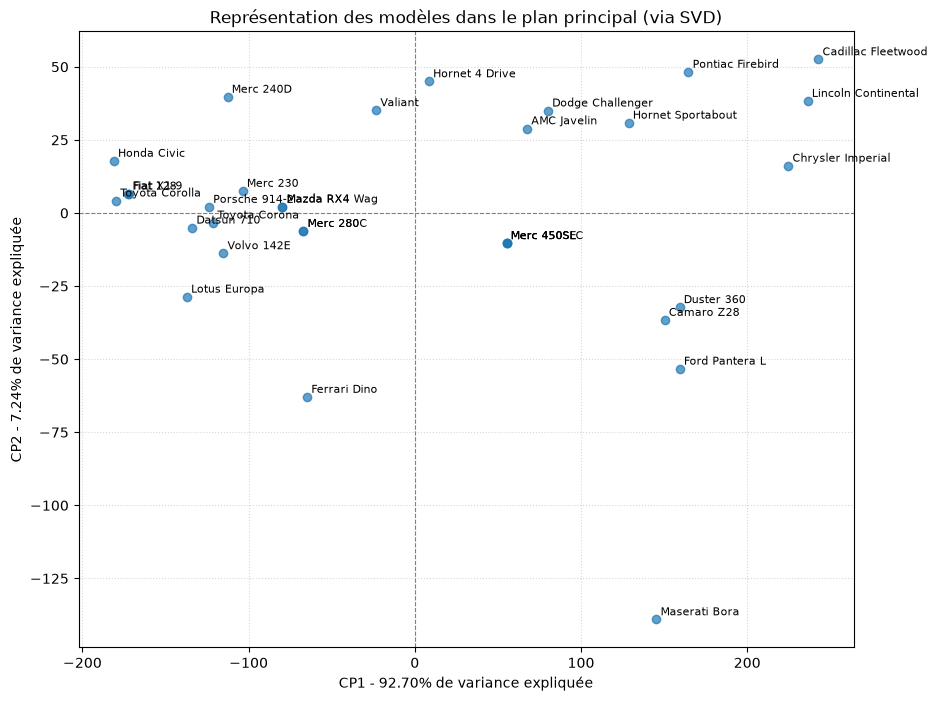

In [104]:
import matplotlib.pyplot as plt

modele= df_cars['model'].values
plt.figure(figsize=(10, 8))
plt.scatter(CP1, CP2, alpha=0.7)

for i in range(len(CP1)):
    plt.annotate(modele[i], (CP1[i], CP2[i]), fontsize=8, xytext=(3, 3), textcoords='offset points')

plt.axhline(0, color='grey', linewidth=0.8, linestyle='--')
plt.axvline(0, color='grey', linewidth=0.8, linestyle='--')

plt.xlabel(f"CP1 - {var_svd[0]:.2f}% de variance expliquée")
plt.ylabel(f"CP2 - {var_svd[1]:.2f}% de variance expliquée")
plt.title("Représentation des modèles dans le plan principal (via SVD)")
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

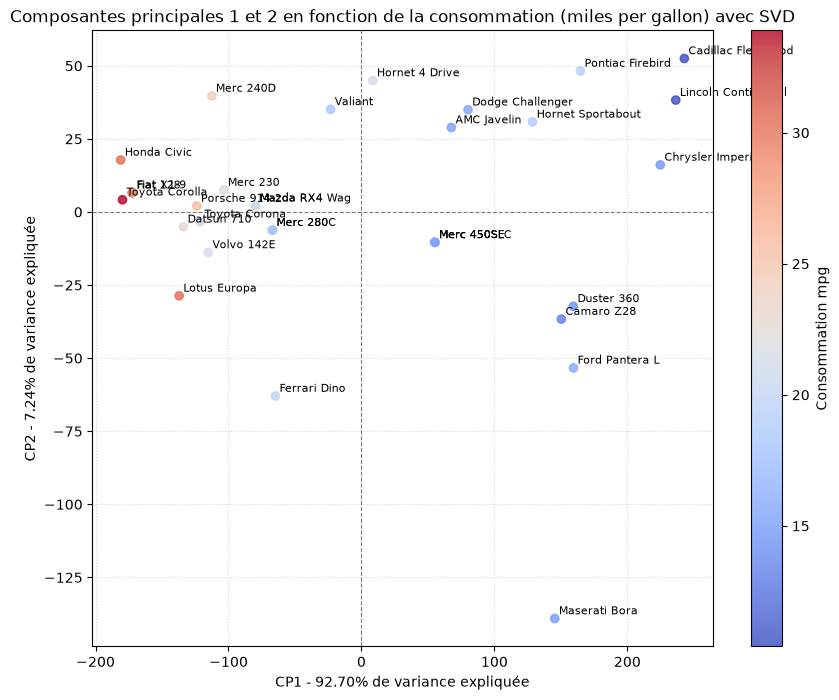

In [108]:

plt.figure(figsize=(10, 8))
sc = plt.scatter(CP1, CP2,
                  c=df_cars['mpg'], cmap='coolwarm', alpha=0.8)

plt.axhline(0, color='grey', linewidth=0.8, linestyle='--')
plt.axvline(0, color='grey', linewidth=0.8, linestyle='--')

# Annotation de chaque point avec le nom du modèle
for i in range(len(CP1)):
    plt.annotate(modele[i], (CP1[i], CP2[i]), fontsize=8, xytext=(3, 3), textcoords='offset points')


plt.xlabel(f"CP1 - {var_svd[0]:.2f}% de variance expliquée")
plt.ylabel(f"CP2 - {var_svd[1]:.2f}% de variance expliquée")
plt.title("Composantes principales 1 et 2 en fonction de la consommation (miles per gallon) avec SVD")
plt.colorbar(sc, label='Consommation mpg')
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

# On obtient les mêmes résultats qu'avec la PCA avec la matrice V car ici on prend les données Z centrées, on ne les a pas réduites 